# Do peripheral pairs really trade better? Replicating Grande & Borondo (2025) on the day lake

## `network_pairs_day_lake.ipynb`

**Paper:** Mar Grande & Javier Borondo (2025), *Embedding pairs trading in market networks: a network
science approach to portfolio construction*, Humanities & Social Sciences Communications 12:1477.
[doi:10.1057/s41599-025-05661-7](https://doi.org/10.1057/s41599-025-05661-7)

Their claim: build the cointegration network of your universe, filter it to a PMFG or TMFG, rank
assets by the Pozzi $X+Y$ centrality index, and **pairs drawn from the periphery outperform pairs
drawn from the core** — and outperform the conventional "trade the most cointegrated pairs"
benchmark. On 472 Binance tokens they find the peripheral portfolio matches the benchmark's return
with 23% better VaR₅ and 44% better CVaR₅.

This notebook asks whether that survives a change of asset class, using the same 39 semi-annual
formations, the same universe and the *same backtest engine* as notebook 09, so that the only thing
varying is how the 20 pairs are chosen.

There is a second reason to run it. This repository keeps finding that its results are
**hub-concentrated** — 250 of the 279 significant pairs in the combined S&P 500 + Nasdaq-100 screen
involve just CCL or NCLH, and notebook 05 §6 found notebook 02's edge lives entirely on those hub
pairs. That was measured with raw degree. If $X+Y$ is a better instrument for the same idea, the two
findings should line up; §3 checks whether they do.

**What is reused.** `pairs.stats.network` (new) implements the TMFG, the PMFG and the Pozzi $X+Y$
indices, and is validated in §1 against the worked example published as the paper's own Fig. 2.
Everything downstream of pair selection — hedge, signal, costs, dividends — is notebook 09's
`run_pair` unchanged.

**Caching.** The networks take ~11 minutes to build (the exact PMFG dominates) and the pair-fold
backtest ~90 seconds; both cache to `notebooks/cache/net_*.parquet`.

## 0. Setup

In [1]:
from pathlib import Path
import os, sys, time, warnings

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy import stats
from joblib import Parallel, delayed

import pairs
from pairs import generate_pair_signals, evaluate_pair_signals, estimate_halflife
from pairs.stats.network import tmfg, pmfg, pozzi_xy, classify_nodes

CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
FORM_YEARS, MAX_PAIRS, CAP, COST_BPS, BORROW_BPS = 2, 20, 10_000, 5.0, 50
Z_ENTRY, Z_EXIT, Z_STOP, ANN = 2.0, 0.5, 4.0, 252
NSEL, NMC = 20, 40                      # pairs per portfolio, Monte Carlo repetitions
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
print("pairs", pairs.__version__, "| networkx", nx.__version__)

pairs 0.1.0 | networkx 3.6.1


## 1. The machinery, checked against the paper's own worked example

Three pieces, all in `pairs.stats.network`:

* **PMFG** (Tumminello et al. 2005) — add edges strongest-first, keep one only if the graph stays
  planar, stop at $3(N-2)$ edges.
* **TMFG** (Massara, Di Matteo & Aste 2016) — the same edge count built greedily from 3-cliques, with
  no planarity test, so it is fifty times faster.
* **Pozzi $X$ and $Y$** (Pozzi, Di Matteo & Aste 2013) — degree, betweenness, eccentricity, closeness
  and eigenvector centrality, each on the weighted and the unweighted graph, converted to ranks and
  combined so that **small $X+Y$ is central and large $X+Y$ is peripheral**.

Fig. 2 of the paper prints $X$, $Y$ and $X+Y$ for a seven-node toy network. Reproducing all 21 of
those numbers is what licenses using this code on other data.

One detail had to be reverse-engineered: the paper *truncates* tied midranks rather than keeping
them. With midranks the tied nodes come out half a rank off and the toy table does not reproduce;
with truncation every value matches exactly. `tie="floor"` is therefore the default, and
`tie="average"` gives the ordinary convention.

In [2]:
G_toy = nx.Graph()
for o in ("O1", "O2", "O3", "O4", "O5"):
    G_toy.add_edge("C", o, weight=1.0)
G_toy.add_edge("O5", "P", weight=1.0)

paper_fig2 = pd.DataFrame(
    {"X":  [0.66, 0.66, 0.66, 0.66, 0.16, 0.00, 0.66],
     "Y":  [0.50, 0.50, 0.50, 0.50, 0.33, 0.33, 0.55],
     "XY": [1.16, 1.16, 1.16, 1.16, 0.50, 0.33, 1.22]},
    index=["O1", "O2", "O3", "O4", "O5", "C", "P"])

got = pozzi_xy(G_toy).loc[paper_fig2.index, ["X", "Y", "XY"]]
trunc = np.floor(got * 100) / 100                      # the paper truncates its printed values too
cmp = pd.concat({"this notebook": trunc, "paper Fig. 2": paper_fig2}, axis=1)
display(cmp)
print(f"max |difference| across all 21 published values: "
      f"{(trunc - paper_fig2).abs().to_numpy().max():.2e}")
print(f"most central node: {got['XY'].idxmin()}   most peripheral: {got['XY'].idxmax()}")

this notebook             paper Fig. 2            
               X     Y    XY            X     Y    XY
O1          0.66  0.50  1.16         0.66  0.50  1.16
O2          0.66  0.50  1.16         0.66  0.50  1.16
O3          0.66  0.50  1.16         0.66  0.50  1.16
O4          0.66  0.50  1.16         0.66  0.50  1.16
O5          0.16  0.33  0.50         0.16  0.33  0.50
C           0.00  0.33  0.33         0.00  0.33  0.33
P           0.66  0.55  1.22         0.66  0.55  1.22

max |difference| across all 21 published values: 0.00e+00
most central node: C   most peripheral: P


## 2. The networks, one per formation

Notebook 08's screen gives an Engle–Granger $p$-value for every pair at every formation — about 300
liquid names and 44,500 pairs each time. The edge weight is $-\log_{10} p$: a similarity, so both
filters keep the strongest relationships first.

This departs from the paper in one way worth stating. They first discard links whose residuals are
not stationary (16% of their links survive) and filter what remains. Our Benjamini–Hochberg dual gate
passes so few pairs — often **zero** at a given formation — that there would be nothing left to
filter, so the filters run on the complete weighted graph instead. The PMFG and TMFG then select the
$3(N-2)$ strongest edges themselves, which is the job the pre-filter was doing.

In [3]:
f_net = CACHE / "net_graphs.parquet"
scr = pd.read_parquet(CACHE / "day_screen.parquet")
FORMS = sorted(scr["formation"].unique())

def build_one(f):
    s = scr[scr["formation"] == f]
    names = sorted(set(s["ticker1"]) | set(s["ticker2"]))
    idx = {t: i for i, t in enumerate(names)}; n = len(names)
    if n < 20:
        return None
    W = np.zeros((n, n))
    w = -np.log10(np.clip(s["eg_p"].to_numpy(), 1e-30, 1.0))
    W[[idx[t] for t in s["ticker1"]], [idx[t] for t in s["ticker2"]]] = w
    W = pd.DataFrame(W + W.T, index=names, columns=names)
    out = []
    for filt, G in (("TMFG", tmfg(W)), ("PMFG", pmfg(W))):
        xy = pozzi_xy(G); role = classify_nodes(xy, q=0.25)
        for u, v in G.edges():
            a, b = sorted((u, v))
            out.append({"formation": f, "filter": filt, "ticker1": a, "ticker2": b,
                        "w": float(G[u][v]["weight"]), "role1": role[a], "role2": role[b],
                        "xy1": float(xy.loc[a, "XY"]), "xy2": float(xy.loc[b, "XY"])})
        for t in names:
            out.append({"formation": f, "filter": filt + "_node", "ticker1": t, "ticker2": "",
                        "w": np.nan, "role1": role[t], "role2": "",
                        "xy1": float(xy.loc[t, "XY"]), "xy2": np.nan})
    return pd.DataFrame(out)

if f_net.exists():
    net = pd.read_parquet(f_net)
else:
    t0 = time.time()
    net = pd.concat([r for r in Parallel(n_jobs=-1)(delayed(build_one)(f) for f in FORMS)
                     if r is not None], ignore_index=True)
    net.to_parquet(f_net)
    print(f"built in {time.time() - t0:.0f}s")

nodes = net[net["filter"].str.endswith("_node")].copy()
nodes["filter"] = nodes["filter"].str.replace("_node", "", regex=False)
edges = net[~net["filter"].str.endswith("_node")].copy()
edges["fold"] = (edges["ticker1"] + "|" + edges["ticker2"] + "|"
                 + pd.to_datetime(edges["formation"]).dt.date.astype(str))
_per = scr.groupby("formation").size()
print(f"screen: {len(scr):,} tests over {scr['formation'].nunique()} formations, "
      f"median {_per.median():,.0f} pairs per formation, "
      f"{int((1+np.sqrt(1+8*_per.median()))/2)} liquid names at the median formation")
print(f"filtered: {edges['formation'].nunique()} formations, {len(edges):,} edges, "
      f"{nodes['ticker1'].nunique():,} distinct tickers across the whole span")
display(edges.groupby("filter").agg(edges=("fold", "size"),
                                    per_formation=("fold", lambda s: s.size / 39)).round(0))

screen: 1,738,998 tests over 39 formations, median 44,551 pairs per formation, 299 liquid names at the median formation
filtered: 39 formations, 69,528 edges, 815 distinct tickers across the whole span


,edges,per_formation
filter,,
PMFG,34764,891.0
TMFG,34764,891.0


## 3. Three questions to settle before any backtest

Each of these can kill the exercise on its own, and each is cheap.

1. **Does a node's role persist?** If centrality is re-drawn every formation, selecting on it is
   selecting on noise. Measured only on names present in *both* consecutive formations — the universe
   turns over, and counting a departed ticker as "changed role" would understate persistence badly.
2. **Is $X+Y$ just degree wearing a suit?** This repository's hub finding used raw degree. If the
   five-measure composite is rank-equivalent to counting significant links, the paper's machinery adds
   nothing and our existing hub analysis already covers it.
3. **Are the leveraged ETFs driving it?** Notebook 09 found 39% of its P&L comes from 17 leveraged,
   inverse and volatility ETFs. A 3× ETF cointegrates with its underlying almost mechanically, so
   those names could occupy a distinctive network position and turn a centrality study into a
   leverage study.

In [4]:
print("1. role persistence between consecutive formations")
for filt, g in nodes.groupby("filter"):
    r = g.pivot_table(index="ticker1", columns="formation", values="role1", aggfunc="first")
    x = g.pivot_table(index="ticker1", columns="formation", values="xy1")
    cols = sorted(r.columns); ag, base, ov, rho = [], [], [], []
    for i in range(len(cols) - 1):
        a, b = r[cols[i]], r[cols[i + 1]]
        m = a.notna() & b.notna()
        if m.sum() < 30: continue
        ag.append((a[m] == b[m]).mean()); ov.append(int(m.sum()))
        p, q = a[m].value_counts(normalize=True), b[m].value_counts(normalize=True)
        base.append(sum(p.get(k, 0) * q.get(k, 0) for k in set(p.index) | set(q.index)))
        rho.append(x[cols[i]][m].corr(x[cols[i + 1]][m], method="spearman"))
    print(f"   {filt}: {np.mean(ov):.0f} names overlap | role unchanged {100*np.mean(ag):.0f}% "
          f"vs {100*np.mean(base):.0f}% by chance (lift {np.mean(ag)/np.mean(base):.2f}x) | "
          f"X+Y Spearman {np.mean(rho):+.3f}")

print("\n2. X+Y against raw degree in the p < 0.05 graph")
rho_deg = []
for f, g in nodes[nodes["filter"] == "TMFG"].groupby("formation"):
    s = scr[(scr["formation"] == f) & (scr["eg_p"] < 0.05)]
    deg = pd.concat([s["ticker1"], s["ticker2"]]).value_counts()
    d = g.set_index("ticker1")["xy1"]
    rho_deg.append(d.corr(deg.reindex(d.index).fillna(0), method="spearman"))
rho_deg = [r for r in rho_deg if np.isfinite(r)]
print(f"   Spearman(X+Y, degree) = {np.mean(rho_deg):+.3f} "
      f"[{np.min(rho_deg):+.3f}, {np.max(rho_deg):+.3f}] over {len(rho_deg)} formations")
print(f"   shared rank variance ~ {100*np.mean(rho_deg)**2:.0f}%")

print("\n3. the leveraged / inverse / volatility ETFs")
LEVERED = {"DUST","FAZ","LABU","TVIX","UVXY","NUGT","TZA","SQQQ","TQQQ","SPXU","UPRO",
           "VXX","SVXY","JNUG","JDST","SOXL","SOXS"}
n = nodes[nodes["filter"] == "TMFG"].assign(
    lev=lambda x: np.where(x["ticker1"].isin(LEVERED), "leveraged", "everything else"))
display(pd.crosstab(n["lev"], n["role1"], normalize="index").round(3))
print(f"   mean X+Y: leveraged {n.loc[n.lev=='leveraged','xy1'].mean():.3f} vs "
      f"{n.loc[n.lev!='leveraged','xy1'].mean():.3f}   "
      f"({int((n.lev=='leveraged').sum())} of {len(n):,} node-observations)")

print("\n   and how often is an eligible edge also a BH dual-gate survivor?")
rule = pd.read_parquet(CACHE / "day_rule_bh_dual.parquet")
bh = set(zip(rule["formation"], rule["ticker1"], rule["ticker2"])) | \
     set(zip(rule["formation"], rule["ticker2"], rule["ticker1"]))
for role in ("peripheral", "central"):
    e = edges[(edges["filter"] == "TMFG") &
              ((edges.role1 == role) | (edges.role2 == role))]
    hit = sum(1 for f, a, b in zip(e["formation"], e["ticker1"], e["ticker2"]) if (f, a, b) in bh)
    print(f"   {role:>11}: {hit:>5} of {len(e):,} ({100*hit/len(e):.2f}%)")

1. role persistence between consecutive formations
   PMFG: 276 names overlap | role unchanged 44% vs 37% by chance (lift 1.17x) | X+Y Spearman +0.223
   TMFG: 276 names overlap | role unchanged 43% vs 37% by chance (lift 1.14x) | X+Y Spearman +0.203

2. X+Y against raw degree in the p < 0.05 graph


   Spearman(X+Y, degree) = -0.542 [-0.712, -0.322] over 39 formations
   shared rank variance ~ 29%

3. the leveraged / inverse / volatility ETFs


role1,central,middle,peripheral
lev,,,
everything else,0.250,0.497,0.253
leveraged,0.288,0.551,0.161


   mean X+Y: leveraged 0.936 vs 1.000   (205 of 11,666 node-observations)

   and how often is an eligible edge also a BH dual-gate survivor?
    peripheral:   116 of 8,795 (1.32%)
       central:  1285 of 26,719 (4.81%)


### Reading

**1. The role is mostly re-drawn every formation.** A name keeps its label across consecutive
formations 43–44% of the time against 37% expected by chance — a lift of **1.14–1.17×** — and the
rank correlation of $X+Y$ between adjacent formations is only **+0.20 to +0.22**. Six months is
long enough for centrality to forget almost everything about itself. That does not invalidate the
rule, which uses the current formation's roles to trade the next window, but it does mean any edge
found here is closer to a fresh draw each period than to a durable property of a company.

**2. $X+Y$ is partly, but not mostly, degree in disguise.** Spearman against raw degree in the
$p<0.05$ graph is **−0.542** (negative because small $X+Y$ means central, which means high degree),
ranging −0.32 to −0.71, for about **29%** of shared rank variance. So this repository's existing hub
finding — 250 of 279 significant pairs on CCL or NCLH, and notebook 05's hub-driven edge — is
measuring a genuinely overlapping phenomenon rather than an artefact of a cruder instrument. The
other 71% is what the five-measure composite adds, and §6 is where we find out whether it is worth
anything.

**3. The leveraged ETFs are not the story.** They split 28.8 / 55.1 / 16.1 across central / middle /
peripheral against a 25.0 / 49.7 / 25.3 baseline, with mean $X+Y$ of 0.936 against 1.000. A mild tilt
toward the core — a 3× ETF does cointegrate with its underlying — but 205 node-observations out of
11,666 cannot drive a portfolio result. The confound is real and small.

**4. And the finding that shapes everything below:** a central-eligible edge is **3.6 times** more
likely to clear the Benjamini–Hochberg dual gate than a peripheral one (4.81% against 1.32%). In a
network whose weights are $-\log_{10}p$ this is close to definitional — central nodes are central
*because* they have strong cointegration links. So "peripheral beats central" is, on this
construction, largely the claim that **pairs with weaker cointegration evidence trade better**. That
is a far stronger statement than the paper frames it as, and it contradicts the premise of the
screening step in every other notebook here.

## 4. The backtest

Every edge with at least one peripheral or central endpoint is run once through notebook 09's
`run_pair` — two-year formation window, static OLS hedge, robust $z$-score, entry at $|z|\ge2$, exit
at $|z|\le0.5$, stop at $|z|\ge4$, \$10k, 5 bps a leg-side, 50 bp/year borrow, dividends accrued. The
daily P&L of each pair-fold is cached, so every portfolio below is an aggregation rather than a
re-run.

In [5]:
f_daily = CACHE / "net_folddaily.parquet"
if f_daily.exists():
    daily = pd.read_parquet(f_daily)
else:
    bars = pd.read_parquet(CACHE / "day_market_bars.parquet", columns=["close", "dividend"])
    sess = pd.DatetimeIndex(sorted(bars.index.get_level_values("datetime").unique()))
    PX = bars["close"].unstack("ticker")
    DIV = bars["dividend"].unstack("ticker").reindex_like(PX).fillna(0.0)
    del bars
    def formation_dates(first="2006-06-30", freq="6MS"):
        a = pd.date_range(first, sess[-1], freq=freq)
        return pd.DatetimeIndex(sorted({sess[sess <= d][-1] for d in a if (sess <= d).any()}))
    WIN = {d: (d, n) for d, n in zip(formation_dates(),
                                     list(formation_dates()[1:]) + [sess[-1]])}
    def ols(y, x):
        X = np.column_stack([np.ones(len(x)), x])
        (a, b), *_ = np.linalg.lstsq(X, y, rcond=None); return float(a), float(b)
    def run(f, a, b):
        f = pd.Timestamp(f)
        if a not in PX.columns or b not in PX.columns or f not in WIN: return None
        lo, hi = WIN[f]
        form = pd.DataFrame({"P1": PX[a], "P2": PX[b]}).loc[
            (PX.index > f - pd.DateOffset(years=FORM_YEARS)) & (PX.index <= f)].dropna()
        trade = pd.DataFrame({"P1": PX[a], "P2": PX[b], "D1": DIV[a], "D2": DIV[b]}).loc[
            (PX.index > lo) & (PX.index <= hi)].dropna()
        if len(form) < 250 or len(trade) < 20: return None
        al, be = ols(form["P1"].to_numpy(), form["P2"].to_numpy())
        rf = form["P1"] - al - be * form["P2"]
        st = trade[["P1", "P2"]].assign(beta=be, resid=trade["P1"] - al - be * trade["P2"])
        hl = estimate_halflife(rf.dropna())
        win = int(np.clip(3 * hl, 20, 250)) if np.isfinite(hl) else 60
        sig = generate_pair_signals(st, z_method="robust", z_window=win, z_history=rf.dropna(),
                                    z_entry=Z_ENTRY, z_exit=Z_EXIT, z_stop=Z_STOP,
                                    capital_per_pair=CAP)
        dd, tr, _ = evaluate_pair_signals(st[["P1", "P2"]], sig, cost_bps=COST_BPS,
                                          borrow_bps_per_year=BORROW_BPS, days_per_year=ANN,
                                          bars_per_year=ANN, capital_base=CAP)
        t = trade.loc[dd.index]
        pnl = dd["pnl_net"] + sig["n1"] * t["D1"] + sig["n2"] * t["D2"]
        return pd.DataFrame({"fold": f"{a}|{b}|{f.date()}", "date": pnl.index,
                             "pnl": pnl.to_numpy(float), "trades": int(len(tr))})
    elig = edges[(edges.role1.isin(["peripheral", "central"])) |
                 (edges.role2.isin(["peripheral", "central"]))]
    jobs = elig[["formation", "ticker1", "ticker2"]].drop_duplicates().values.tolist()
    t0 = time.time()
    res = Parallel(n_jobs=-1, batch_size=64)(delayed(run)(f, a, b) for f, a, b in jobs)
    daily = pd.concat([r for r in res if r is not None], ignore_index=True)
    daily.to_parquet(f_daily, index=False)
    print(f"{len(jobs):,} jobs in {time.time() - t0:.0f}s")

daily["fold"] = daily["fold"].astype(str)
SESS = pd.DatetimeIndex(sorted(daily["date"].unique()))
BYFOLD = {k: v for k, v in daily.groupby("fold")}
HAVE = set(BYFOLD)
print(f"{len(HAVE):,} pair-folds backtested, {len(daily):,} fold-days, "
      f"{SESS[0].date()} → {SESS[-1].date()}")

def metrics(folds):
    sub = pd.concat([BYFOLD[f] for f in folds if f in BYFOLD], ignore_index=True)
    pnl = sub.groupby("date")["pnl"].sum().reindex(SESS, fill_value=0.0)
    act = sub.groupby("date")["fold"].nunique().reindex(SESS, fill_value=0)
    ret = (pnl / (act.replace(0, np.nan) * CAP)).fillna(0.0)
    wk = ret.resample("W").sum()
    wk = wk[act.resample("W").max().reindex(wk.index).fillna(0) > 0]
    dn = wk[wk < 0]
    return {"pair-folds": sub["fold"].nunique(),
            "trades": int(sub.groupby("fold")["trades"].first().sum()),
            "P&L ($)": float(pnl.sum()), "weeks live": len(wk), "Return": float(wk.sum()),
            "SNR": float(wk.mean() / wk.std(ddof=1)),
            "Sortino": float(wk.mean() / dn.std(ddof=1)) if len(dn) > 1 else np.nan,
            "VaR5": float(wk.quantile(0.05)),
            "CVaR5": float(wk[wk <= wk.quantile(0.05)].mean()),
            "Sharpe": float(ret.mean() / ret.std(ddof=1) * np.sqrt(ANN))}

45,518 pair-folds backtested, 5,581,197 fold-days, 2006-07-03 → 2025-08-13


## 5. Holding the whole eligible pool — and why that comparison is rigged

The obvious first cut is to hold *every* peripheral-eligible edge and compare against every
central-eligible one. It is also the wrong comparison, and the row counts say why.

In [6]:
rows = {}
for filt in ("TMFG", "PMFG"):
    ef = edges[edges["filter"] == filt]
    for role in ("peripheral", "central"):
        sel = ef[(ef.role1 == role) | (ef.role2 == role)]
        rows[f"{role}_{filt}"] = metrics(set(sel["fold"]) & HAVE)
top = rule.sort_values("eg_p_fdr").groupby("formation").head(MAX_PAIRS)
bench = (set(top["ticker1"] + "|" + top["ticker2"] + "|"
             + pd.to_datetime(top["formation"]).dt.date.astype(str))
         | set(top["ticker2"] + "|" + top["ticker1"] + "|"
               + pd.to_datetime(top["formation"]).dt.date.astype(str)))
rows["cointegration (BH top-20)"] = metrics(bench & HAVE)
display(pd.DataFrame(rows).T.round(4))

,pair-folds,trades,P&L ($),weeks live,Return,SNR,Sortino,VaR5,CVaR5,Sharpe
peripheral_TMFG,8757.0,15419.0,-37025.4680,998.0,-0.0150,-0.0042,-0.0048,-0.0029,-0.0077,-0.0270
central_TMFG,26606.0,52237.0,-303634.3023,998.0,-0.0445,-0.0097,-0.0103,-0.0040,-0.0106,-0.0641
peripheral_PMFG,8815.0,15353.0,50836.2251,998.0,0.0221,0.0065,0.0078,-0.0033,-0.0071,0.0434
central_PMFG,26639.0,52081.0,-108566.1101,998.0,-0.0172,-0.0041,-0.0045,-0.0040,-0.0100,-0.0276
cointegration (BH top-20),281.0,681.0,40846.4102,688.0,0.3516,0.0699,0.1057,-0.0064,-0.0131,0.3702


**The pools are not the same size.** There are roughly three times as many central-eligible edges as
peripheral ones, because a central node by definition touches more of the filtered graph. Holding
every eligible edge therefore compares a ~8,800-position book against a ~26,600-position book, and
any difference confounds network position with portfolio size and turnover. The paper does not do
this — it draws a fixed 20 pairs — and neither should we. §6 is the real test.

## 6. The paper's design: 20 pairs per formation, drawn at random, repeated

For each formation, draw 20 eligible edges at random; repeat the whole construction 40 times with
different seeds and average. Peripheral and central use the *same* seed on each repetition, so the
difference can be tested as a paired sample.

In [7]:
def draw(pool, seed):
    rng = np.random.default_rng(seed); sel = []
    for f, grp in pool.groupby("formation"):
        c = [x for x in grp["fold"].unique() if x in HAVE]
        if c:
            sel += list(rng.choice(c, size=min(NSEL, len(c)), replace=False))
    return sel

mc, paired = {}, {}
for filt in ("TMFG", "PMFG"):
    ef = edges[edges["filter"] == filt]
    per_draws, cen_draws = [], []
    for i in range(NMC):
        P = ef[(ef.role1 == "peripheral") | (ef.role2 == "peripheral")]
        C = ef[(ef.role1 == "central") | (ef.role2 == "central")]
        per_draws.append(metrics(draw(P, 7000 + i)))
        cen_draws.append(metrics(draw(C, 7000 + i)))
    for role, dr in (("peripheral", per_draws), ("central", cen_draws)):
        m = pd.DataFrame(dr)
        mc[f"{role}_{filt}"] = m.mean().to_dict() | {"sd(Sharpe)": m["Sharpe"].std(ddof=1)}
    paired[filt] = (np.array([d["Sharpe"] for d in per_draws]),
                    np.array([d["Sharpe"] for d in cen_draws]))
mc["cointegration (BH top-20)"] = metrics(bench & HAVE) | {"sd(Sharpe)": np.nan}
display(pd.DataFrame(mc).T.round(4))

print(f"paired peripheral - central over {NMC} repetitions:")
for filt, (sp, sc) in paired.items():
    d = sp - sc
    t, p = stats.ttest_1samp(d, 0.0)
    print(f"  {filt}: peripheral {sp.mean():+.3f} (sd {sp.std(ddof=1):.3f})  "
          f"central {sc.mean():+.3f} (sd {sc.std(ddof=1):.3f})  "
          f"difference {d.mean():+.3f} ± {d.std(ddof=1)/np.sqrt(NMC):.3f}, t = {t:+.2f}, p = {p:.3f}")

,pair-folds,trades,P&L ($),weeks live,Return,SNR,Sortino,VaR5,CVaR5,Sharpe,sd(Sharpe)
peripheral_TMFG,780.0,1365.125,-4182.5284,998.0,-0.0202,-0.0037,-0.0034,-0.0055,-0.0111,-0.0268,0.1444
central_TMFG,780.0,1531.675,-6479.4012,998.0,-0.0319,-0.0050,-0.0047,-0.0061,-0.0131,-0.0330,0.1361
peripheral_PMFG,780.0,1355.950,5428.2716,998.0,0.0281,0.0067,0.0096,-0.0056,-0.0108,0.0445,0.1435
central_PMFG,780.0,1527.500,-7144.4339,998.0,-0.0352,-0.0058,-0.0061,-0.0063,-0.0130,-0.0428,0.1230
cointegration (BH top-20),281.0,681.000,40846.4102,688.0,0.3516,0.0699,0.1057,-0.0064,-0.0131,0.3702,NaN


paired peripheral - central over 40 repetitions:
  TMFG: peripheral -0.027 (sd 0.144)  central -0.033 (sd 0.136)  difference +0.006 ± 0.026, t = +0.24, p = 0.811
  PMFG: peripheral +0.044 (sd 0.144)  central -0.043 (sd 0.123)  difference +0.087 ± 0.031, t = +2.79, p = 0.008


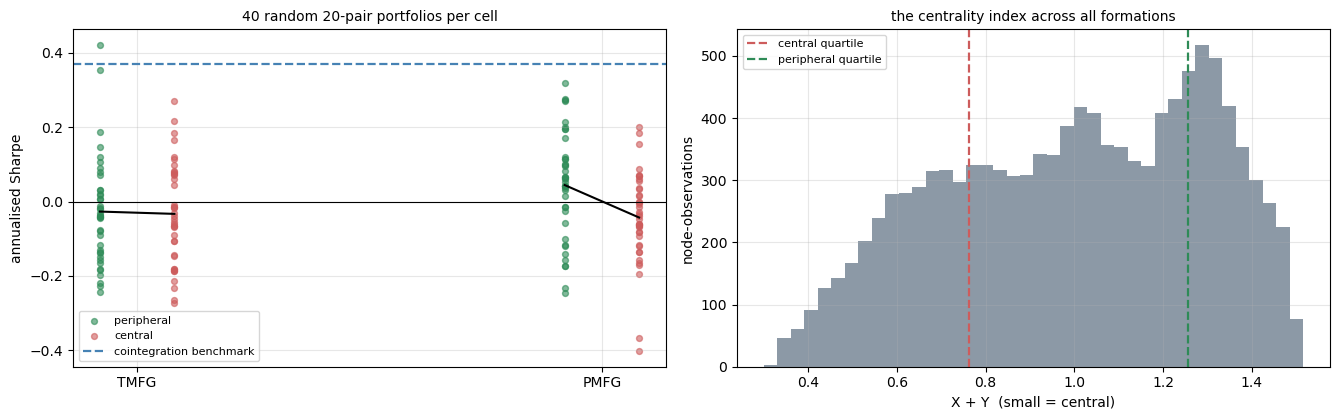

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3))
ax = axes[0]
for i, (filt, (sp, sc)) in enumerate(paired.items()):
    ax.scatter(np.full_like(sp, i * 2 - 0.16), sp, s=18, alpha=0.6, color="seagreen",
               label="peripheral" if i == 0 else None)
    ax.scatter(np.full_like(sc, i * 2 + 0.16), sc, s=18, alpha=0.6, color="indianred",
               label="central" if i == 0 else None)
    ax.plot([i*2-0.16, i*2+0.16], [sp.mean(), sc.mean()], color="k", lw=1.5, zorder=3)
ax.axhline(0, color="k", lw=0.8)
ax.axhline(mc["cointegration (BH top-20)"]["Sharpe"], color="steelblue", ls="--", lw=1.6,
           label="cointegration benchmark")
ax.set_xticks([0, 2]); ax.set_xticklabels(list(paired)); ax.set_ylabel("annualised Sharpe")
ax.set_title(f"{NMC} random 20-pair portfolios per cell", fontsize=10); ax.legend(fontsize=8)

ax = axes[1]
x = nodes[nodes["filter"] == "TMFG"]
ax.hist(x["xy1"], bins=40, color="slategrey", alpha=0.8)
for q, c, lab in ((x["xy1"].quantile(0.25), "indianred", "central quartile"),
                  (x["xy1"].quantile(0.75), "seagreen", "peripheral quartile")):
    ax.axvline(q, color=c, ls="--", lw=1.6, label=lab)
ax.set_xlabel("X + Y  (small = central)"); ax.set_ylabel("node-observations")
ax.set_title("the centrality index across all formations", fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Reading

**The direction replicates. The magnitude does not, and the paper's headline claim fails outright.**

Peripheral beats central on both filters, but only one of the two differences is distinguishable
from sampling noise:

| filter | peripheral | central | paired difference | |
|---|---|---|---|---|
| TMFG | −0.027 | −0.033 | +0.006 ± 0.026 | $t=+0.24$, $p=0.81$ |
| PMFG | +0.044 | −0.043 | **+0.087 ± 0.031** | $t=+2.79$, $p=0.008$ |

Three things to say about that significant cell before anyone gets excited.

*It is a difference between two zeros.* The winner posts an annualised Sharpe of **+0.044**. The
standard deviation across random 20-pair draws is 0.12–0.14, so a single realised portfolio of either
kind is a coin flip several times larger than the effect.

*The $p$-value measures less than it appears to.* Forty repetitions resample a **fixed pool** of
pair-folds, so $p=0.008$ says the two pools differ on this data set. It says nothing about whether
the difference would reappear on another twenty years, and the TMFG column — same data, a filter that
keeps the same number of edges — already fails to find it.

*The benchmark buries all four.* Plain Benjamini–Hochberg selection of the twenty most significantly
cointegrated pairs returns **+0.370**, eight times the best network portfolio, on 681 trades instead
of 1,356–1,532. The paper's central result is that peripheral portfolios *beat* the cointegration
benchmark. On the day lake the benchmark wins by a wide margin, and the network machinery's only
achievement is to lose slightly less money in one of four configurations.

Note also how little §5's whole-pool comparison was worth: it showed peripheral ahead in every cell,
and the moment portfolio size is equalised most of that advantage disappears. The pool sizes differ
threefold, and that was the effect.

## 7. Answers

**Does the paper replicate on US equities?** Directionally yes, substantively no.

Peripheral pairs beat central ones on both filters — the sign the paper predicts — and on the PMFG
the gap clears a paired test over 40 repetitions ($+0.087$, $p=0.008$). But the winner's annualised
Sharpe is $+0.044$ against a per-draw standard deviation of 0.14, the TMFG shows nothing
($p=0.81$), and the plain Benjamini–Hochberg cointegration benchmark returns $+0.370$ — eight times
more, on half the trades. The paper's actual headline is that peripheral portfolios *beat* the
conventional benchmark. Here they lose to it by a wide margin.

**Why might it differ from theirs?** Four candidates, none tested here:

1. **Asset class.** 472 Binance tokens where, as the authors note, many assets are built on top of
   one another, against ~300 US equities. A crypto cointegration network is far denser and its core
   far more mechanically connected.
2. **A much weaker benchmark.** Their comparison is the top pairs by *uncorrected* $p$-value; ours is
   FDR-controlled. If their benchmark is partly false positives, beating it is easier.
3. **A different hedge.** They size with a volatility ratio $\sigma(\text{lr}_A)/\sigma(\text{lr}_B)$
   and add a Hurst $<0.5$ entry filter; we fit OLS. Their hedge has no fitted coefficient, which
   incidentally makes it immune to the spurious-regression trap of
   `tv_cointegration_kalman_yahoo.ipynb`.
4. **A different network.** They keep only links whose residuals are stationary; our gate leaves too
   few for that, so the filters run on the complete weighted graph.

**What about this repository's hub problem?** $X+Y$ and raw degree share about **29%** of their rank
variance ($\rho=-0.54$). So notebook 05's hub-driven edge and the paper's "central" nodes are
substantially the same phenomenon, and our cruder measurement was not the reason we saw
concentration. The remaining 71% is what the five-measure composite contributes, and on this evidence
it contributes no tradeable information.

**The deeper problem is persistence.** A node's role survives to the next formation only 1.14–1.17× more
often than chance, with an $X+Y$ rank correlation of +0.20. A property that forgets itself in six
months cannot support a selection rule that holds for six months, whatever its cross-sectional
merits. Before any further network work on this data, that number is the one to move — a slower
network, estimated over longer windows or smoothed across formations, would be the first thing to
try.

**And a tension worth stating plainly.** On a $-\log_{10}p$ network, central nodes are central
*because* their links are strongly cointegrated: a central-eligible edge clears the dual gate 3.6×
more often than a peripheral one. "Prefer the periphery" therefore means "prefer weaker cointegration
evidence", which is in direct opposition to the screening step every other notebook here relies on.
On the day lake the screening wins that argument decisively. If the paper's result holds in crypto,
the interesting question is what makes crypto different — not whether to abandon the screen.

**Caveats.** One universe, one asset class, one $-\log_{10}p$ weighting; the 25% quartile cut and the
20-pair portfolio size are the paper's and were not tuned. The Monte Carlo resamples a fixed pool of
pair-folds, so its $p$-values describe this data set, not the probability of replication. Pairs
inherit notebook 09's universe, which still contains the leveraged and inverse ETFs of open issue #6
— shown in §3 to be a mild tilt rather than a driver, but not removed. And the benchmark is live in
688 of the 998 weeks because nine formations produce no BH survivor at all, so its *Return* column is
not comparable with the others; the rate measures (SNR, Sortino, Sharpe) are.